# Exploratory data analysis: freight load rates

Goal: understand what drives `posted_rate`, find data-quality defects, and decide how to validate a model that must predict loads two months beyond the labelled period.

Data:
- `train_test.csv` — 48,000 labelled loads, January to October 2025
- `validation.csv` — 12,000 unlabelled loads, November to December 2025, to be predicted

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from freight_rate.config import TRAIN_PATH, VALIDATION_PATH, FIGURES_DIR
from freight_rate.data import haversine_miles, distance_band, rate_outlier_mask

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

train = pd.read_csv(TRAIN_PATH, parse_dates=["date"])
valid = pd.read_csv(VALIDATION_PATH, parse_dates=["date"])
train.shape, valid.shape

Matplotlib is building the font cache; this may take a moment.


((48000, 14), (12000, 13))

## 1. Structure and coverage

In [2]:
train.head()

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


In [3]:
train.describe().T.round(3)

,count,mean,min,25%,50%,75%,max,std
pickup_lat,48000.0,35.647545,28.35765,31.98691,35.29479,39.41104,44.30296,4.315285
pickup_lon,48000.0,-90.928964,-121.69849,-98.40059,-88.08915,-83.28506,-69.5,13.482431
delivery_lat,48000.0,35.641175,28.35765,31.98691,35.29479,39.41104,44.30296,4.317199
delivery_lon,48000.0,-90.85731,-121.69849,-98.40059,-87.52871,-83.28506,-69.5,13.476589
distance,48000.0,1135.856654,70.0,550.4,953.3,1645.525,3439.8,728.564416
weight,47700.0,31028.844004,-47500.0,25800.0,31436.5,37018.0,47500.0,9391.44062
date,48000,2025-05-31 19:53:29.400000,2025-01-01 00:00:00,2025-03-18 00:00:00,2025-05-31 00:00:00,2025-08-15 00:00:00,2025-10-31 00:00:00,NaN
market_index,47626.0,1.083387,0.67639,0.94967,1.0558,1.21959,1.46778,0.168091
quote_signal,48000.0,2.062468,0.69228,1.89103,2.05575,2.221685,3.61035,0.291391
posted_rate,48000.0,2373.980682,57.22,1251.555,2030.76,3330.75,25533.0,1486.493245


In [4]:
coverage = pd.DataFrame({
    "train": [train.date.min().date(), train.date.max().date(), train.date.nunique(), train.pickup.nunique(), (train.pickup + ">" + train.delivery).nunique()],
    "validation": [valid.date.min().date(), valid.date.max().date(), valid.date.nunique(), valid.pickup.nunique(), (valid.pickup + ">" + valid.delivery).nunique()],
}, index=["first date", "last date", "days", "cities", "lanes"])
coverage

,train,validation
first date,2025-01-01,2025-11-01
last date,2025-10-31,2025-12-31
days,304,61
cities,64,72
lanes,4014,4214


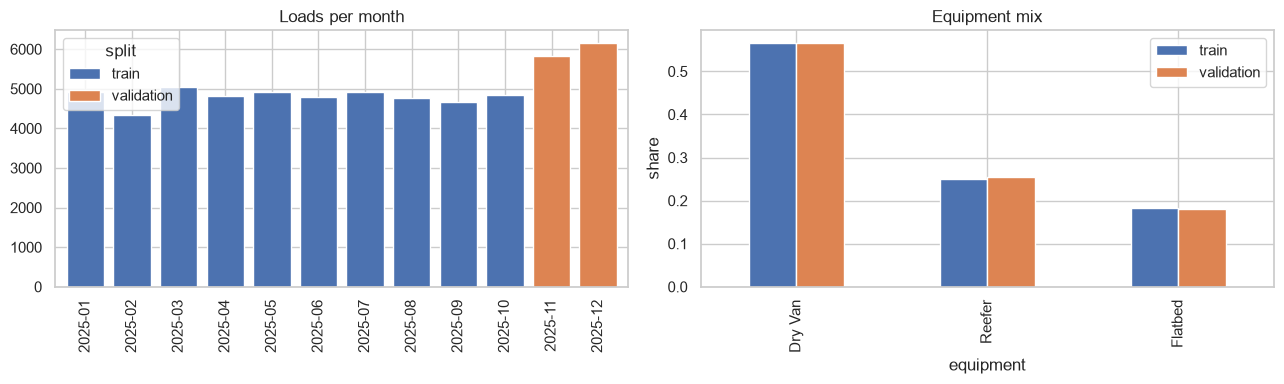

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
monthly = pd.concat([train.assign(split="train"), valid.assign(split="validation")])
monthly.groupby([monthly.date.dt.to_period("M"), "split"]).size().unstack().plot.bar(ax=axes[0], stacked=True, width=0.8)
axes[0].set_title("Loads per month"); axes[0].set_xlabel("")
pd.concat([train.equipment.value_counts(normalize=True).rename("train"), valid.equipment.value_counts(normalize=True).rename("validation")], axis=1).plot.bar(ax=axes[1])
axes[1].set_title("Equipment mix"); axes[1].set_ylabel("share")
plt.tight_layout(); plt.show()

The validation period starts the day after the training period ends, so the task is a genuine two-month forecast. Any validation scheme must respect time order: a random split would let the model see loads from the same days it is scored on.

In [6]:
train_cities = set(train.pickup) | set(train.delivery)
valid_cities = set(valid.pickup) | set(valid.delivery)
new_cities = sorted(valid_cities - train_cities)
touched = valid.pickup.isin(new_cities) | valid.delivery.isin(new_cities)
train_lanes = set(train.pickup + ">" + train.delivery)
new_lanes = ~(valid.pickup + ">" + valid.delivery).isin(train_lanes)
print(f"cities in validation never seen in training: {new_cities}")
print(f"validation loads touching a new city: {touched.sum():,} ({touched.mean():.1%})")
print(f"validation loads on a lane never seen in training: {new_lanes.sum():,} ({new_lanes.mean():.1%})")

cities in validation never seen in training: ['Allentown', 'Charlotte', 'Chicago', 'Jackson', 'Knoxville', 'Laredo', 'Norfolk', 'San Diego']
validation loads touching a new city: 1,447 (12.1%)
validation loads on a lane never seen in training: 1,461 (12.2%)


Twelve percent of the loads to be predicted involve a city that never appears in training, and a third are on unseen lanes. Features must therefore generalise beyond lane identity: distance, coordinates, and equipment carry the signal for those loads, and any city or lane encoding needs a graceful fallback.

## 2. Missing and corrupted values

In [7]:
missing = pd.DataFrame({"train": train.isna().sum(), "validation": valid.isna().sum()})
missing[missing.sum(axis=1) > 0]

,train,validation
market_index,374,249.0
weight,300,165.0


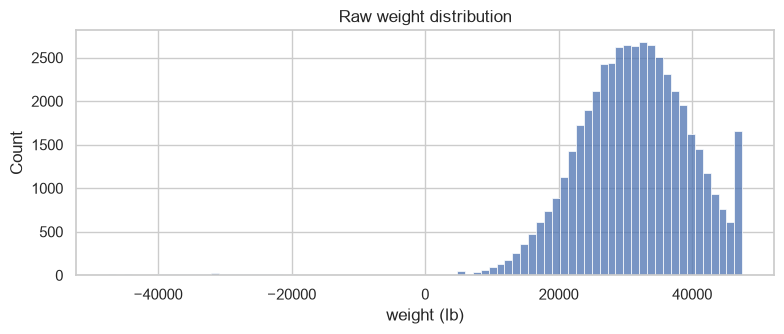

negative weights: 292 train, 145 validation
absolute value range of negatives: 5,000 to 47,500


In [8]:
fig, ax = plt.subplots(figsize=(8, 3.5))
sns.histplot(train.weight, bins=80, ax=ax)
ax.set_title("Raw weight distribution"); ax.set_xlabel("weight (lb)")
plt.tight_layout(); plt.show()
negative = train.weight < 0
print(f"negative weights: {negative.sum()} train, {(valid.weight < 0).sum()} validation")
print(f"absolute value range of negatives: {train.weight[negative].abs().min():,.0f} to {train.weight[negative].abs().max():,.0f}")

In [9]:
rpm = train.posted_rate / train.distance
lane_median = rpm.groupby([train.pickup, train.delivery, train.equipment]).transform("median")
ratio = rpm / lane_median
pd.DataFrame({
    "rows": [negative.sum(), train.weight.isna().sum(), train.market_index.isna().sum()],
    "median rate vs lane median": [ratio[negative].median(), ratio[train.weight.isna()].median(), ratio[train.market_index.isna()].median()],
}, index=["negative weight", "missing weight", "missing market_index"]).round(3)

,rows,median rate vs lane median
negative weight,292,1.0
missing weight,300,1.0
missing market_index,374,1.0


Negative weights mirror the valid range exactly and the rates on those loads are indistinguishable from their lanes, so they are sign flips rather than different loads: an absolute value restores them. Missing weights and market index values are likewise unrelated to the rate, so median imputation with a missing-indicator is sufficient.

## 3. The target: posted rate

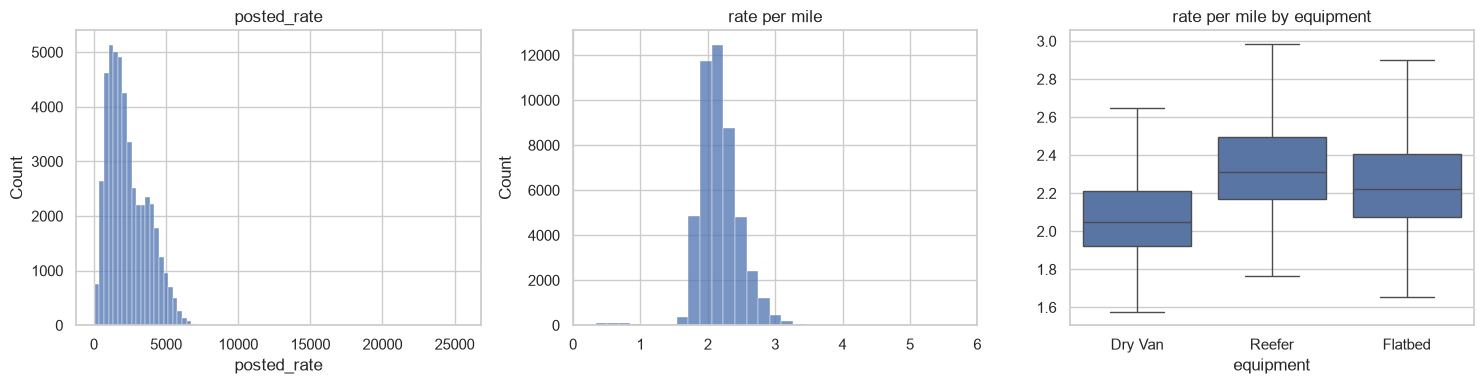

correlation of posted_rate with distance: 0.909


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(train.posted_rate, bins=80, ax=axes[0]); axes[0].set_title("posted_rate")
sns.histplot(rpm, bins=80, ax=axes[1]); axes[1].set_xlim(0, 6); axes[1].set_title("rate per mile")
sns.boxplot(x=train.equipment, y=rpm, ax=axes[2], showfliers=False); axes[2].set_title("rate per mile by equipment"); axes[2].set_ylabel("")
plt.tight_layout(); plt.savefig(FIGURES_DIR / "target_distribution.png", dpi=150); plt.show()
print("correlation of posted_rate with distance:", round(train.posted_rate.corr(train.distance), 3))

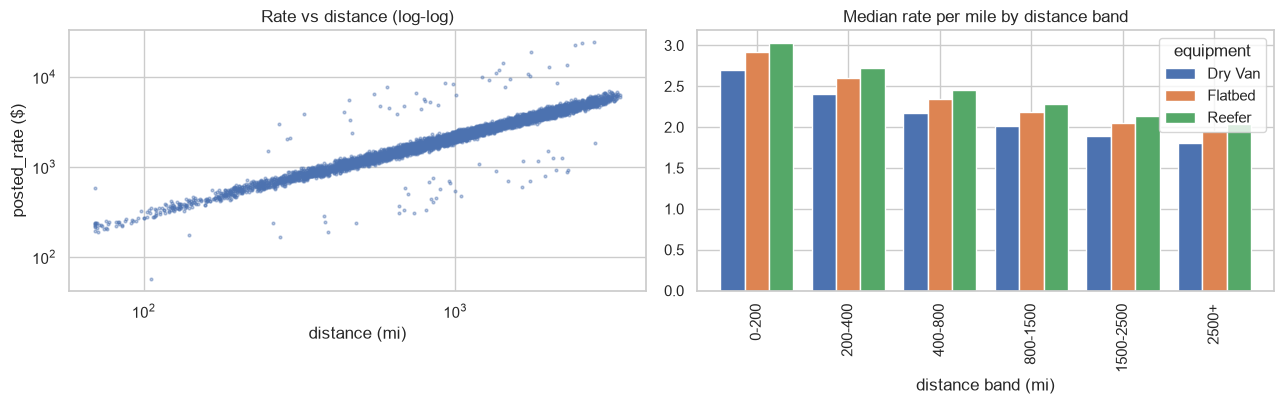

In [11]:
band = distance_band(train.distance)
band_labels = ["0-200", "200-400", "400-800", "800-1500", "1500-2500", "2500+"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
sample = train.sample(6000, random_state=0)
axes[0].scatter(sample.distance, sample.posted_rate, s=4, alpha=0.4)
axes[0].set_xscale("log"); axes[0].set_yscale("log"); axes[0].set_xlabel("distance (mi)"); axes[0].set_ylabel("posted_rate ($)"); axes[0].set_title("Rate vs distance (log-log)")
rpm.groupby([band, train.equipment]).median().unstack().set_axis(band_labels).plot.bar(ax=axes[1], width=0.8)
axes[1].set_title("Median rate per mile by distance band"); axes[1].set_xlabel("distance band (mi)")
plt.tight_layout(); plt.savefig(FIGURES_DIR / "rate_vs_distance.png", dpi=150); plt.show()

Distance explains most of the variance, but the relationship is not proportional: short hauls command a much higher rate per mile, and the decline flattens beyond about 1,500 miles. Equipment adds a roughly constant multiplier, with Reefer above Flatbed above Dry Van. Modelling the log of the rate with a flexible function of log distance captures this shape directly.

## 4. Rate outliers

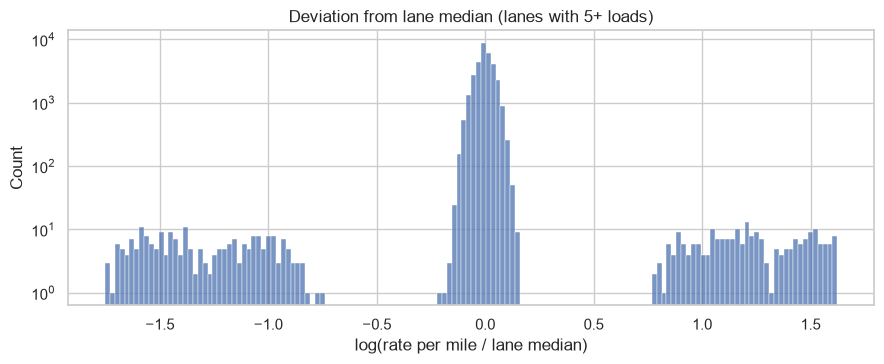

std of log deviation for typical loads: 0.040
quantiles: {0.005: -1.079, 0.01: -0.118, 0.05: -0.074, 0.95: 0.068, 0.99: 0.111, 0.995: 1.09}


In [12]:
log_ratio = np.log(ratio)
counts = rpm.groupby([train.pickup, train.delivery, train.equipment]).transform("size")
fig, ax = plt.subplots(figsize=(9, 3.8))
sns.histplot(log_ratio[counts >= 5], bins=150, ax=ax)
ax.set_yscale("log"); ax.set_xlabel("log(rate per mile / lane median)"); ax.set_title("Deviation from lane median (lanes with 5+ loads)")
plt.tight_layout(); plt.savefig(FIGURES_DIR / "outlier_separation.png", dpi=150); plt.show()
central = log_ratio[(counts >= 5) & (log_ratio.abs() < 0.5)]
print(f"std of log deviation for typical loads: {central.std():.3f}")
print("quantiles:", log_ratio[counts >= 5].quantile([0.005, 0.01, 0.05, 0.95, 0.99, 0.995]).round(3).to_dict())

In [13]:
outlier = rate_outlier_mask(train)
print(f"flagged outliers: {outlier.sum()} ({outlier.mean():.2%})")
ratio[outlier].round(2).value_counts().head(10)

flagged outliers: 677 (1.41%)


1.00    30
0.20    23
0.21    17
0.25    17
0.23    16
0.19    15
0.24    15
0.34    14
0.22    13
0.37    13
Name: count, dtype: int64

Typical loads sit within a few percent of their lane median, while a separate population is priced at roughly three times or a quarter of it. There is nothing in between, so a threshold of a factor of two removes exactly this population. These rows are excluded from model fitting only. The unlabelled validation set almost certainly contains the same corruption, which puts a floor on achievable error that no model can remove.

## 5. Geography

cities with more than one coordinate pair: 0
loads at the 70-mile floor: 48


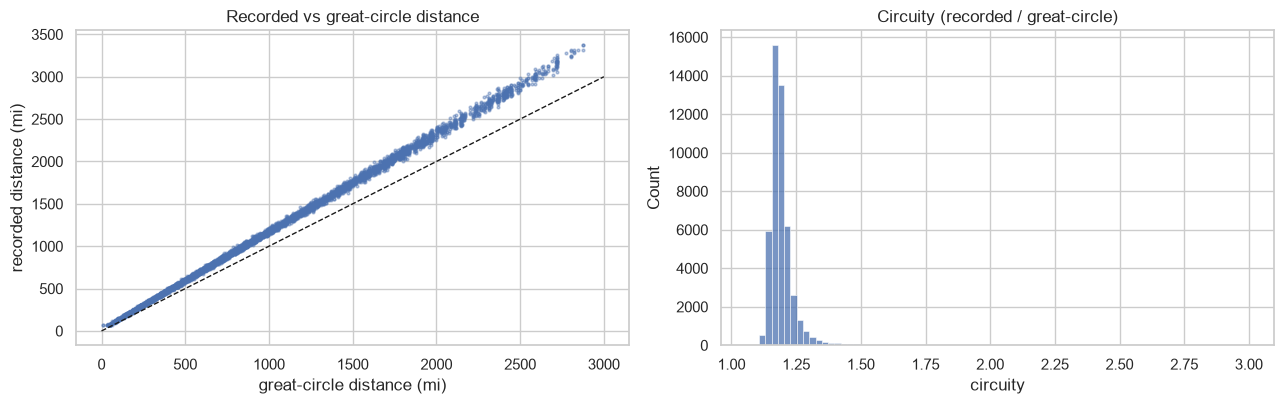

circuity quantiles: {0.01: 1.13, 0.5: 1.182, 0.99: 1.404}


In [14]:
train["haversine"] = haversine_miles(train.pickup_lat, train.pickup_lon, train.delivery_lat, train.delivery_lon)
train["circuity"] = train.distance / train.haversine
coords_per_city = train.groupby("pickup")[["pickup_lat", "pickup_lon"]].nunique().max(axis=1)
print("cities with more than one coordinate pair:", int((coords_per_city > 1).sum()))
print("loads at the 70-mile floor:", int((train.distance == 70).sum()))
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].scatter(sample.assign(h=train.haversine[sample.index]).h, sample.distance, s=4, alpha=0.4)
axes[0].plot([0, 3000], [0, 3000], "k--", lw=1); axes[0].set_xlabel("great-circle distance (mi)"); axes[0].set_ylabel("recorded distance (mi)"); axes[0].set_title("Recorded vs great-circle distance")
sns.histplot(train.circuity.clip(upper=3), bins=80, ax=axes[1]); axes[1].set_title("Circuity (recorded / great-circle)")
plt.tight_layout(); plt.show()
print("circuity quantiles:", train.circuity.quantile([0.01, 0.5, 0.99]).round(3).to_dict())

In [15]:
short = train[train.circuity > 1.6]
print(f"loads with circuity above 1.6: {len(short)}, median great-circle distance {short.haversine.median():.0f} mi, median recorded distance {short.distance.median():.0f} mi")
print(f"their rate per mile vs the 0-200 mile band median: {(short.posted_rate / short.distance).median():.2f} vs {rpm[band == 0].median():.2f}")

loads with circuity above 1.6: 111, median great-circle distance 51 mi, median recorded distance 84 mi
their rate per mile vs the 0-200 mile band median: 2.96 vs 2.80


Coordinates are consistent per city, and recorded distance runs about 18% above the great-circle distance, a normal road factor. The high-circuity tail is entirely short lanes where distance is floored at 70 miles; their rates match other short hauls, so these are not errors and no correction is applied. Circuity is kept as a feature because it marks that floor.

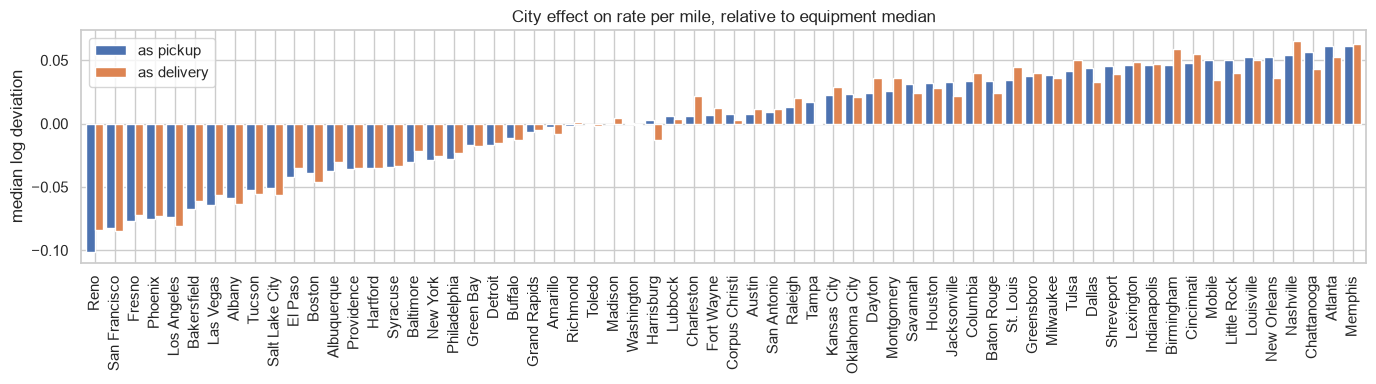

In [16]:
equipment_median = rpm.groupby(train.equipment).transform("median")
city_effect = np.log(rpm / equipment_median)
effects = pd.concat([city_effect.groupby(train.pickup).median().rename("as pickup"), city_effect.groupby(train.delivery).median().rename("as delivery")], axis=1).sort_values("as pickup")
fig, ax = plt.subplots(figsize=(14, 4))
effects.plot.bar(ax=ax, width=0.85); ax.set_ylabel("median log deviation"); ax.set_title("City effect on rate per mile, relative to equipment median"); ax.set_xlabel("")
plt.tight_layout(); plt.savefig(FIGURES_DIR / "city_effects.png", dpi=150); plt.show()

Origin and destination each shift the rate per mile by up to about 10%, with West Coast cities cheap and the Southeast expensive. City identity is therefore a useful categorical feature, and coordinates give the model a way to place unseen cities on the same map.

## 6. Market index and time

market_index spread within a day: 0.025, across days: 0.168


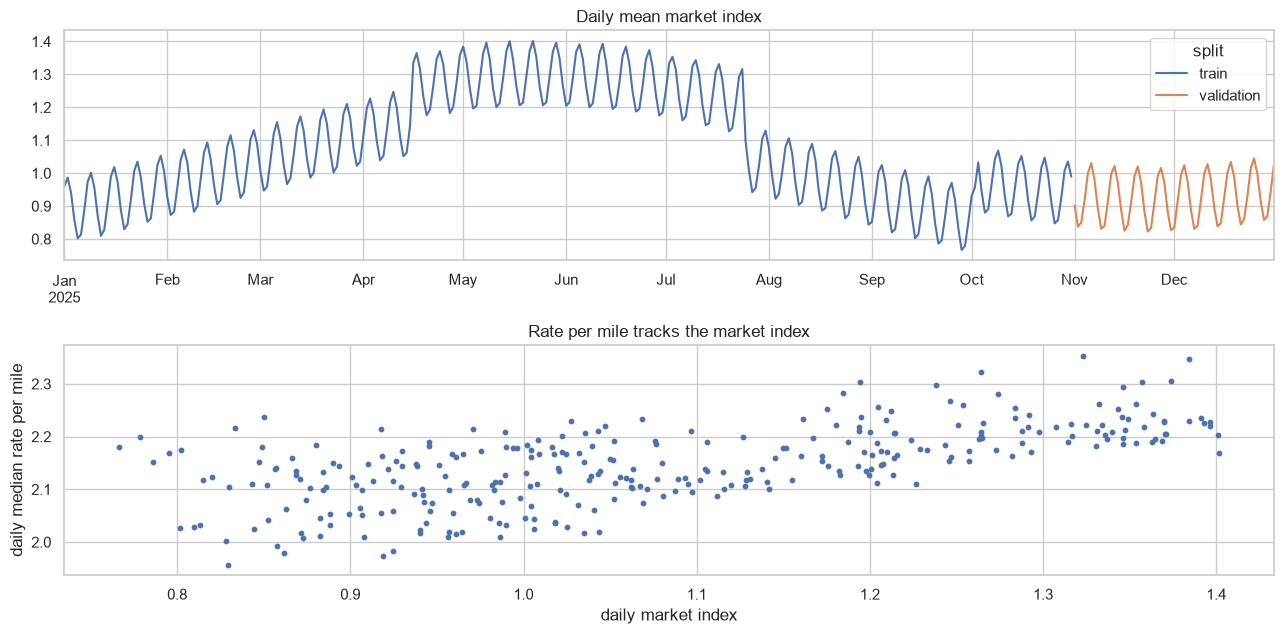

elasticity of rate per mile to market index: 0.14


In [17]:
daily = pd.concat([train.assign(split="train"), valid.assign(split="validation")]).groupby(["date", "split"]).market_index.mean().unstack()
within_day = train.groupby("date").market_index.std().mean()
print(f"market_index spread within a day: {within_day:.3f}, across days: {train.market_index.std():.3f}")
fig, axes = plt.subplots(2, 1, figsize=(13, 6.5), sharex=False)
daily.plot(ax=axes[0]); axes[0].set_title("Daily mean market index"); axes[0].set_xlabel("")
daily_rpm = rpm.groupby(train.date).median()
axes[1].scatter(daily["train"].reindex(daily_rpm.index), daily_rpm, s=10)
axes[1].set_xlabel("daily market index"); axes[1].set_ylabel("daily median rate per mile"); axes[1].set_title("Rate per mile tracks the market index")
plt.tight_layout(); plt.savefig(FIGURES_DIR / "market_index.png", dpi=150); plt.show()
slope = np.polyfit(np.log(daily["train"].reindex(daily_rpm.index)), np.log(daily_rpm), 1)[0]
print(f"elasticity of rate per mile to market index: {slope:.2f}")

The market index is a day-level series with only small per-load jitter. It carries the seasonal shape of rates, with an elasticity near 0.14, and it is already lower in the validation months than in most of the training period. Because the index is given for every validation load, it can be used directly instead of extrapolating calendar seasonality into months the model has never seen.

/var/folders/cl/wd4gzlkd4xl187hsq1qbr7580000gn/T/ipykernel_96718/3608929738.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  clean_rpm.groupby(pd.qcut(clean.weight.abs(), 5)).median().plot.bar(ax=axes[0]); axes[0].set_title("Rate per mile by weight quintile"); axes[0].set_xlabel("")
/var/folders/cl/wd4gzlkd4xl187hsq1qbr7580000gn/T/ipykernel_96718/3608929738.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  clean_rpm.groupby(pd.qcut(clean.quote_signal, 5)).median().plot.bar(ax=axes[1]); axes[1].set_title("Rate per mile by quote_signal quintile"); axes[1].set_xlabel("")


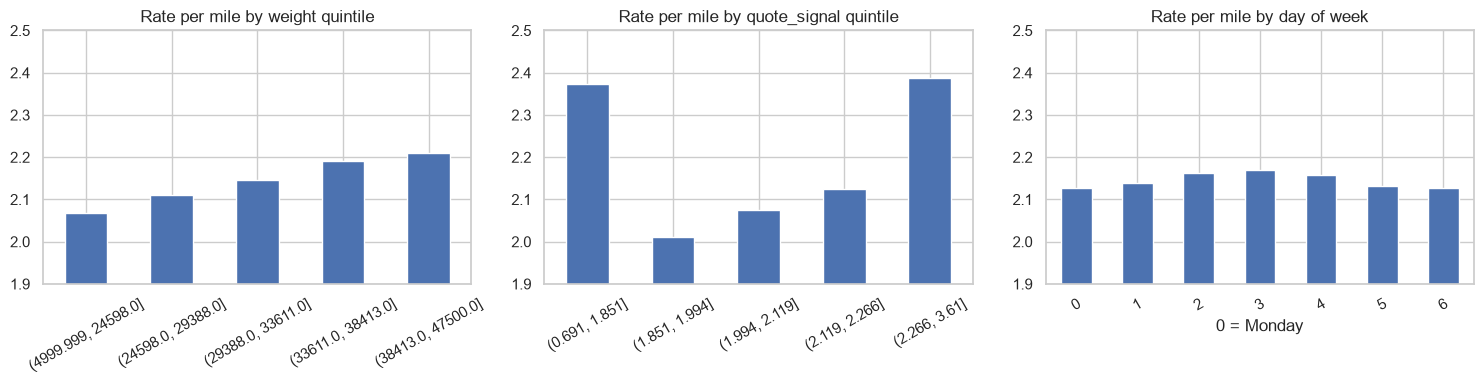

In [18]:
clean = train[~outlier]
clean_rpm = rpm[~outlier]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
clean_rpm.groupby(pd.qcut(clean.weight.abs(), 5)).median().plot.bar(ax=axes[0]); axes[0].set_title("Rate per mile by weight quintile"); axes[0].set_xlabel("")
clean_rpm.groupby(pd.qcut(clean.quote_signal, 5)).median().plot.bar(ax=axes[1]); axes[1].set_title("Rate per mile by quote_signal quintile"); axes[1].set_xlabel("")
clean_rpm.groupby(clean.date.dt.dayofweek).median().plot.bar(ax=axes[2]); axes[2].set_title("Rate per mile by day of week"); axes[2].set_xlabel("0 = Monday")
for ax in axes: ax.set_ylim(1.9, 2.5); ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

Weight adds a mild premium, mid-week loads are slightly dearer, and `quote_signal` has a U-shaped relationship with the rate per mile. None of these dominate, but they are cheap to include; the U shape is a reason to allow non-linear terms.

## 7. Validation strategy

In [19]:
monthly_rpm = pd.DataFrame({"median rate per mile": clean_rpm.groupby(clean.date.dt.to_period("M")).median(), "mean market index": clean.market_index.groupby(clean.date.dt.to_period("M")).mean()})
monthly_rpm.round(3)

,median rate per mile,mean market index
date,,
2025-01,2.029,0.927
2025-02,2.061,0.996
2025-03,2.140,1.073
2025-04,2.147,1.207
2025-05,2.191,1.301
2025-06,2.247,1.280
2025-07,2.187,1.201
2025-08,2.121,0.981
2025-09,2.159,0.893


Rates drift by month with the market, so the model is validated the way it will be used:

1. **Primary holdout.** Train on January to August, score on September to October: a two-month forward window that mirrors the November to December target.
2. **Forward-chaining folds.** Repeat with windows ending in June, August, and October to check the ranking of models is stable across the year.
3. **Scoring.** Mean absolute error and mean absolute percentage error on the raw rate, reported both on all holdout loads and with the corrupted outliers excluded so that model differences are not swamped by rows no model can predict.

## 8. Summary of findings

| Finding | Decision |
|---|---|
| Weight sign flips (0.6% of loads) | Take absolute value |
| Missing weight and market index (under 1% each) | Equipment median and same-day mean, with indicator flags |
| 1.4% of rates at 3x or 0.25x their lane | Exclude from training with a factor-of-two rule |
| Distance floored at 70 miles on short lanes | Keep; add circuity as a feature |
| Eight unseen cities, a third of lanes unseen | Coordinates and distance-based features; encoders that ignore unknown categories |
| Rate is multiplicative in distance, equipment, cities, and market index | Model log rate; spline in log distance for linear models |
| Validation period is strictly later | Time-ordered holdout and forward-chaining folds |